Code for Experiment 5
----------------------

This notebook contains the python code used to analyze the data collected during Experiment 5 of the paper "Building Compressed Causal Models of the World."

In [1]:
#Import all required packages.

import os
os.environ['R_HOME']='/Library/Frameworks/R.framework/Resources' #The home for R on your computer may differ. 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import pingouin as pg
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

/Users/davidkinney/anaconda3/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


The following block of code imports and cleans the data in the file 'study_s2_data.csv'.

In [2]:
data = pd.read_csv('study_s2_data.csv')
data=data.drop(labels=0,axis=0) 
data=data.drop(labels=1,axis=0)
data = data[data.Status == 'IP Address']
exclusions = []
for i in range(2,len(data)):
    if data.threshold[i] == '50' and (data.P_MD_A_2C[i] == 'No' or data.P_MD_B_2C[i] == 'No' or data.P_MD_C_2C[i] == 'Yes' or\
                                              data.P_MD_D_2C[i] == 'Yes' or data.T_MD_A_2C[i] == 'No' or data.T_MD_B_2C[i] == 'No' or\
                                              data.T_MD_C_2C[i] == 'Yes' or data.T_MD_D_2C[i] == 'Yes'):
        exclusions = np.append(exclusions,[i])
    if data.threshold[i] == '80' and (data.P_MD_A_2C[i] == 'No' or data.P_MD_B_2C[i] == 'Yes' or data.P_MD_C_2C[i] == 'Yes' or\
                                              data.P_MD_D_2C[i] == 'Yes' or data.T_MD_A_2C[i] == 'No' or data.T_MD_B_2C[i] == 'Yes' or\
                                              data.T_MD_C_2C[i] == 'Yes' or data.T_MD_D_2C[i] == 'Yes'):
        exclusions = np.append(exclusions,[i])
        
data=data.drop(labels=exclusions,axis=0)
data = data.reset_index()

code = np.loadtxt('study_s1_final_codes.csv',dtype='str',delimiter=',')
for i in range(0,4):
    s = str(i+1)
    data['code' + s]=code[:,i].tolist()
data = data.reset_index()

The next block counts the number of responses that received each of the four codes for both the case where VOLI is zero and the case where VOLI is positive. The numbers in the .csv correspond to the following codes:

1: COMPRESSED IMPLICIT

2: HIGH

3: DIFF

4: COMPRESSED EXPLICIT

In [3]:
zero_1 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '1' or data.code2[i] == '1' or data.code3[i] == '1' or data.code4[i] == '1') and data.threshold[i] == '50':
        zero_1 = zero_1 + 1
        
zero_2 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '2' or data.code2[i] == '2' or data.code3[i] == '2' or data.code3[i] == '2') and data.threshold[i] == '50':
        zero_2 = zero_2 + 1
        
zero_3 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '3' or data.code2[i] == '3' or data.code3[i] == '3' or data.code3[i] == '3') and data.threshold[i] == '50':
        zero_3 = zero_3 + 1
        
zero_4 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '4' or data.code2[i] == '4' or data.code3[i] == '4' or data.code3[i] == '4' ) and data.threshold[i] == '50':
        zero_4 = zero_4 + 1
        
pos_1 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '1' or data.code2[i] == '1' or data.code3[i] == '1' or data.code4[i] == '1') and data.threshold[i] == '80':
        pos_1 = pos_1 + 1
        
pos_2 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '2' or data.code2[i] == '2' or data.code3[i] == '2' or data.code3[i] == '2') and data.threshold[i] == '80':
        pos_2 = pos_2 + 1
        
pos_3 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '3' or data.code2[i] == '3' or data.code3[i] == '3' or data.code3[i] == '3') and data.threshold[i] == '80':
        pos_3 = pos_3 + 1
        
pos_4 = 0
for i in range(0,len(data)):
    if (data.code1[i] == '4' or data.code2[i] == '4' or data.code3[i] == '4' or data.code3[i] == '4') and data.threshold[i] == '80':
        pos_4 = pos_4 + 1
        
total_zero = np.sum([1 for i in range(0,len(data)) if data.threshold[i] == '50'])
total_pos = np.sum([1 for i in range(0,len(data)) if data.threshold[i] == '80'])

The next block produces the bar plot showing the results of the experiment.

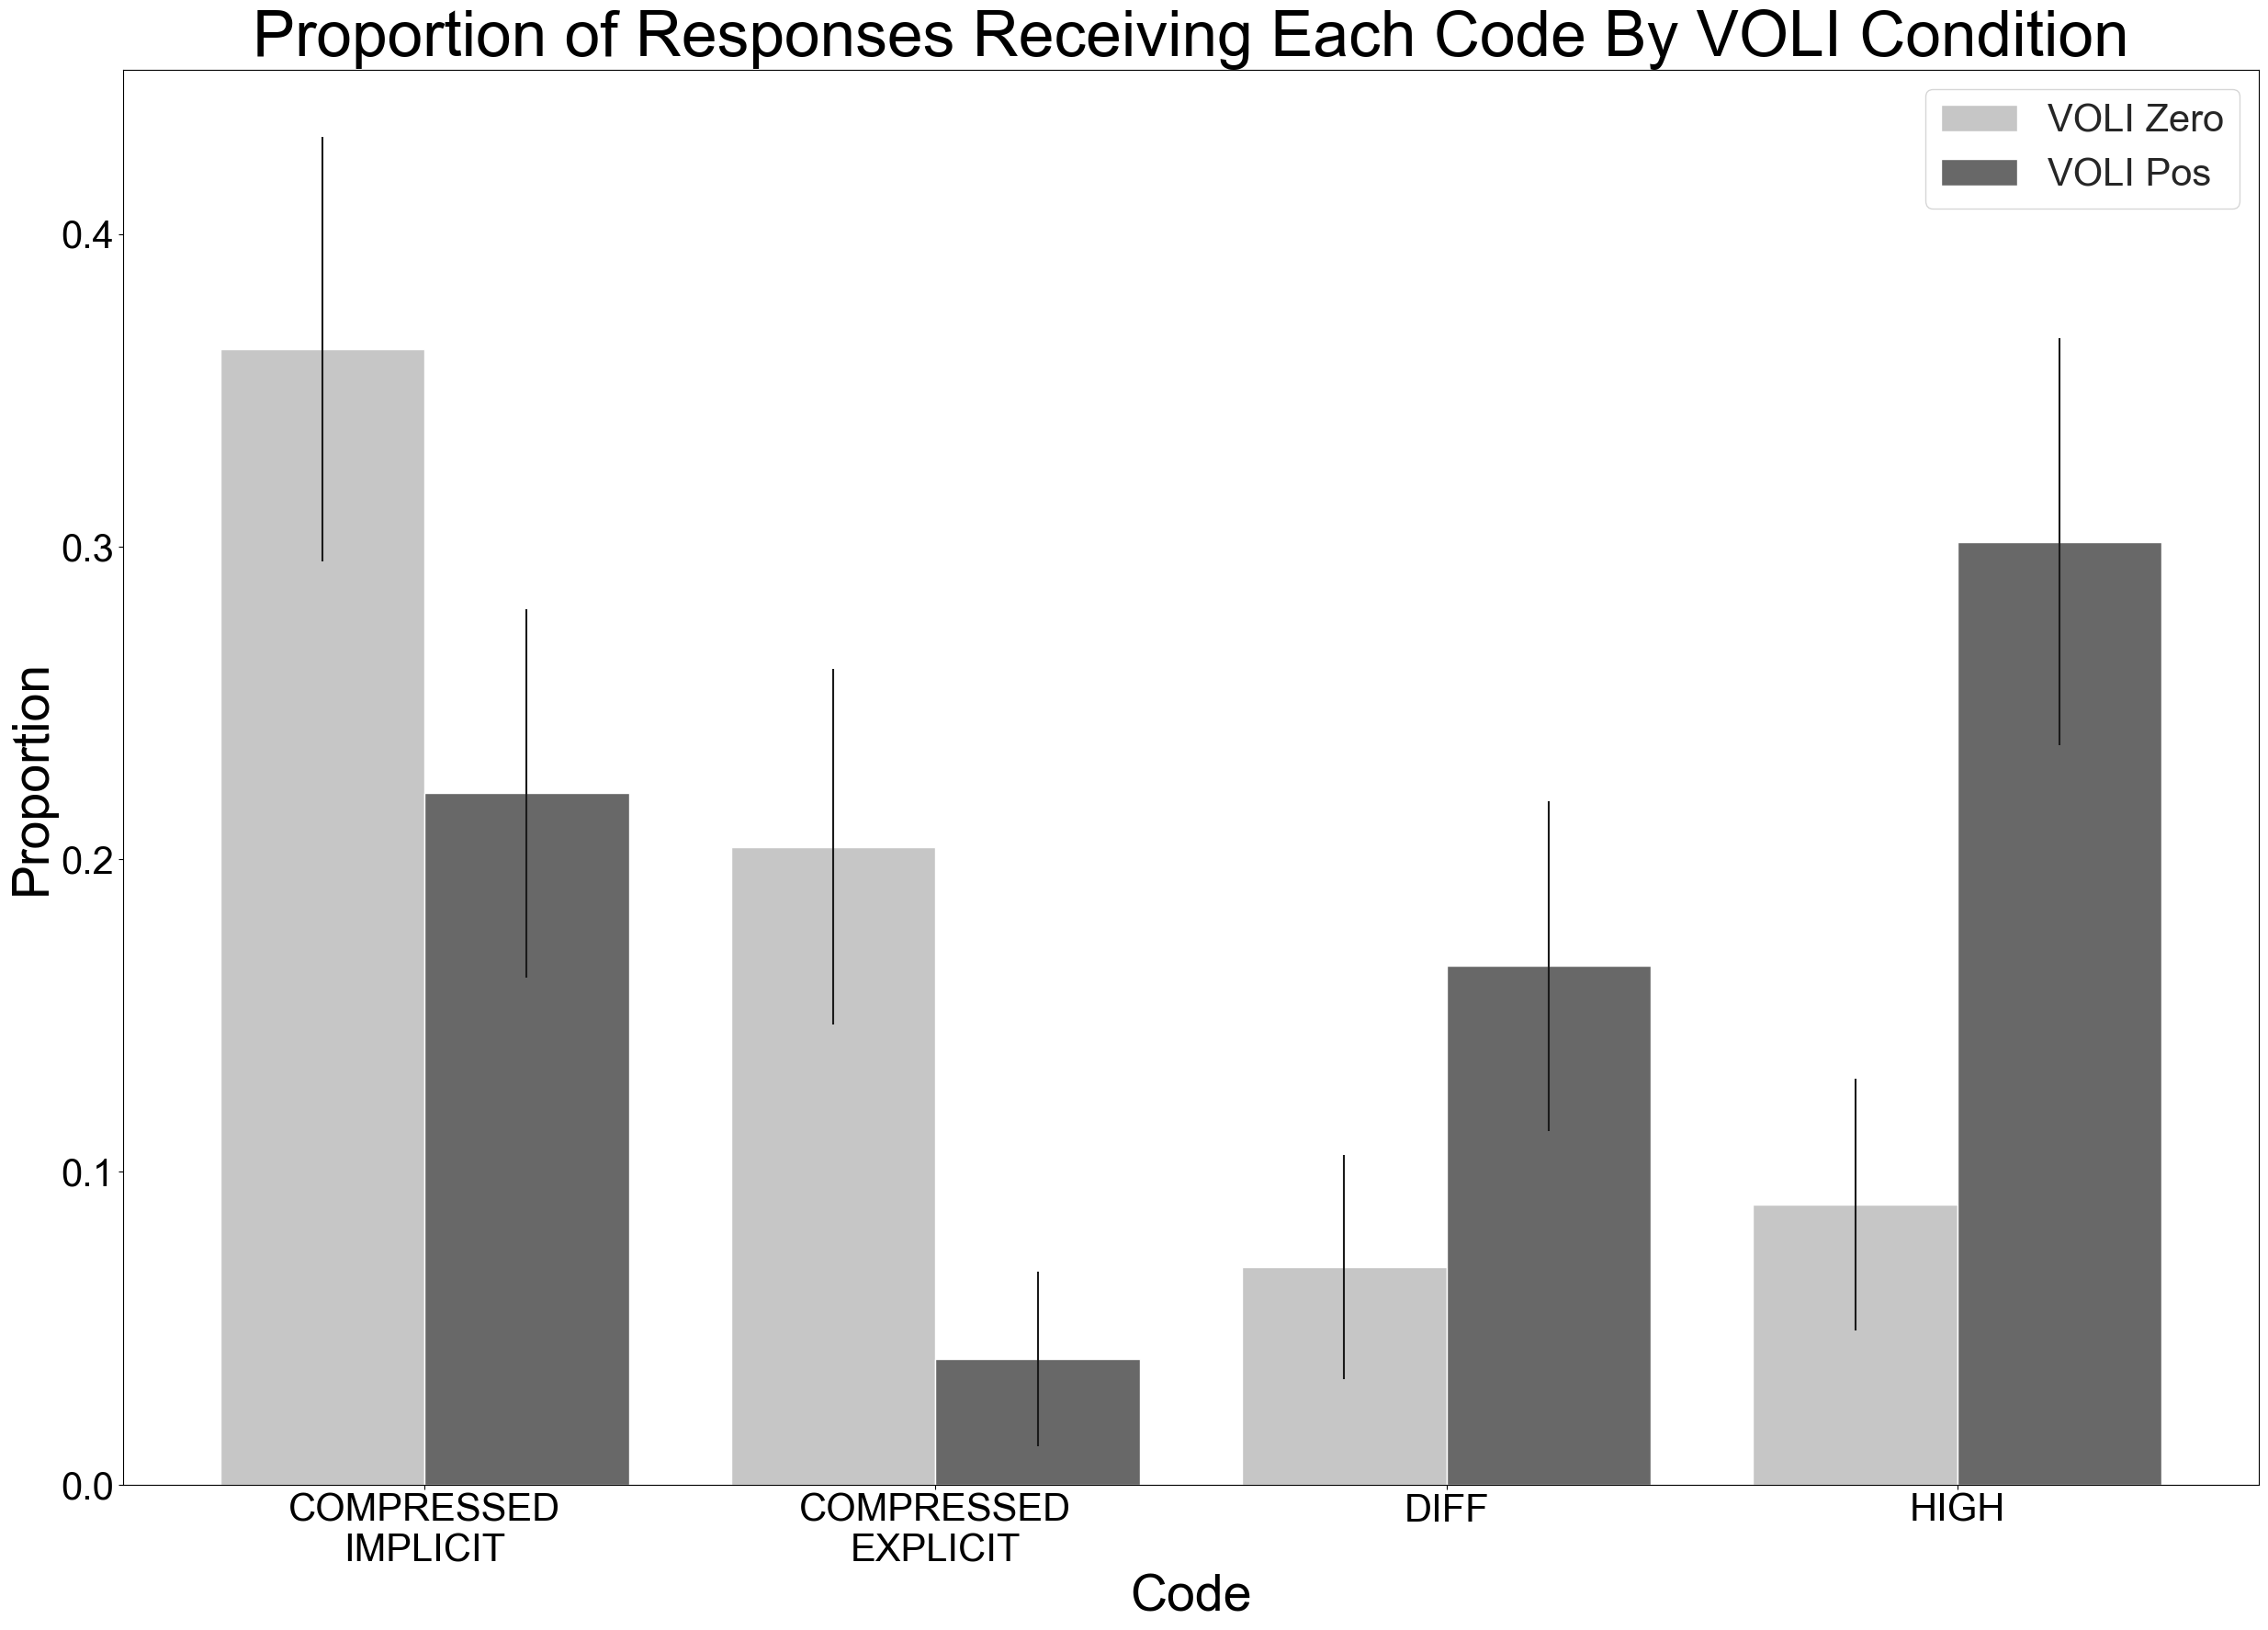

In [4]:
df = pd.DataFrame({
    'Code': ['COMPRESSED\nIMPLICIT', 'COMPRESSED\nEXPLICIT','DIFF','HIGH'],
    'VOLI Zero': [zero_1/total_zero, zero_4/total_zero, zero_3/total_zero, zero_2/total_zero],
    'VOLI Pos': [pos_1/total_pos, pos_4/total_pos, pos_3/total_pos, pos_2/total_pos],
})
fig, ax1 = plt.subplots(figsize=(30, 20))
tidy = df.melt(id_vars='Code', value_name = 'Percentage', var_name = 'Condition')

sns.set(rc = {'figure.figsize':(30,20)})
sns.set_style('whitegrid')
ax = sns.barplot(x='Code', y='Percentage', hue='Condition', palette='Greys', data=tidy, ax=ax1)
x_coords = [p.get_x() + 0.5*p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]
yerr = [2*np.sqrt(zero_1/total_zero*(1-zero_1/total_zero)/total_zero),2*np.sqrt(zero_4/total_zero*(1-zero_4/total_zero)/total_zero),
        2*np.sqrt(zero_3/total_zero*(1-zero_3/total_zero)/total_zero),\
       2*np.sqrt(zero_2/total_zero*(1-zero_2/total_zero)/total_zero),\
       2*np.sqrt(pos_1/total_pos*(1-pos_1/total_pos)/total_pos),2*np.sqrt(pos_4/total_pos*(1-pos_4/total_pos)/total_pos),\
        2*np.sqrt(pos_3/total_pos*(1-pos_3/total_pos)/total_pos),2*np.sqrt(pos_2/total_pos*(1-pos_2/total_pos)/total_pos),\
       ]#This line defines the standard error for each bar, allowing us to draw error bars.
plt.errorbar(x=x_coords, y=y_coords, yerr=yerr, fmt="none", c= "k")
ax1.set_xlabel('Code',fontsize=40)
ax1.set_ylabel('Proportion',fontsize=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.legend(fontsize=30)
ax1.set_title('Proportion of Responses Receiving Each Code By VOLI Condition',fontsize=50)
plt.savefig('coding_plot_5.png')

The next block defines arrays storing all of the key independent variables: VOLI, Loss, Vignette, and Mode of Compression, and all interactions between them.

In [5]:
voli = np.array([-1 if data.threshold[i]=='50' else 1 for i in range(0,len(data))])
loss = np.array([.01 if data.prob[i]=='85' else .06 for i in range(0,len(data))])
vignette = np.array([-1 if data.vignette[i]=='pharma' else 1 for i in range(0,len(data))])
mode = np.array([-1 if data.condition[i]=='proportionality' else 1 for i in range(0,len(data))])
loss_voli = np.array([loss[i]*voli[i] for i in range(0,len(data))])
mode_voli = np.array([mode[i]*voli[i] for i in range(0,len(data))])
mode_loss = np.array([loss[i]*mode[i] for i in range(0,len(data))])
vignette_voli = np.array([vignette[i]*voli[i] for i in range(0,len(data))])
mode_vignette = np.array([vignette[i]*mode[i] for i in range(0,len(data))])
vignette_loss = np.array([vignette[i]*loss[i] for i in range(0,len(data))])
vignette_loss_voli = np.array([vignette[i]*loss[i]*voli[i] for i in range(0,len(data))])
vignette_loss_mode = np.array([vignette[i]*loss[i]*mode[i] for i in range(0,len(data))])
voli_loss_mode = np.array([voli[i]*loss[i]*mode[i] for i in range(0,len(data))])
voli_vignette_mode = np.array([voli[i]*vignette[i]*mode[i] for i in range(0,len(data))])
voli_vignette_mode_loss = np.array([voli[i]*vignette[i]*mode[i]*loss[i] for i in range(0,len(data))])

The next block runs a logistic regression of a binary variable denoting whether or note a response received the code COMPRESSED IMPLICIT against all the vectors defined above.

In [12]:
code_1_bin = np.array([1 if (data.code1[i] == '1' or data.code2[i] == '1' or data.code3[i] == '1' or data.code4[i] == '1') else 0 for i in range(0,len(data))])
arr = np.hstack((code_1_bin.reshape(-1,1),voli.reshape(-1,1),loss.reshape(-1,1),mode.reshape(-1,1),\
                 vignette.reshape(-1,1),loss_voli.reshape(-1,1),vignette_voli.reshape(-1,1),vignette_loss.reshape(-1,1),\
                 mode_loss.reshape(-1,1),mode_vignette.reshape(-1,1),mode_voli.reshape(-1,1),\
                 vignette_loss_voli.reshape(-1,1),vignette_loss_mode.reshape(-1,1),voli_loss_mode.reshape(-1,1),\
                voli_vignette_mode.reshape(-1,1),voli_vignette_mode_loss.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Code_1_Bin', 'VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI','Vignette:Loss:VOLI',\
                              'Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode',\
                       'VOLI:Vignette:Mode:Loss'])
X = sm.add_constant(df[['VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI',\
                        'Vignette:Loss:VOLI','Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode',\
                       'VOLI:Vignette:Mode:Loss']])
y = df['Code_1_Bin']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.565259
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             Code_1_Bin   No. Observations:                  400
Model:                          Logit   Df Residuals:                      384
Method:                           MLE   Df Model:                           15
Date:                Wed, 23 Aug 2023   Pseudo R-squ.:                 0.06472
Time:                        21:56:00   Log-Likelihood:                -226.10
converged:                       True   LL-Null:                       -241.75
Covariance Type:            nonrobust   LLR p-value:                  0.008026
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.9734      0.205     -4.743      0.000      -1.376   

The next block runs a logistic regression of a binary variable denoting whether or note a response received the code HIGH against all the vectors defined above.

In [13]:
code_2_bin = np.array([1 if (data.code1[i] == '2' or data.code2[i] == '2' or data.code3[i] == '2' or data.code4[i] == '2') else 0 for i in range(0,len(data))])
arr = np.hstack((code_2_bin.reshape(-1,1),voli.reshape(-1,1),loss.reshape(-1,1),mode.reshape(-1,1),\
                 vignette.reshape(-1,1),loss_voli.reshape(-1,1),vignette_voli.reshape(-1,1),vignette_loss.reshape(-1,1),\
                 mode_loss.reshape(-1,1),mode_vignette.reshape(-1,1),mode_voli.reshape(-1,1),\
                 vignette_loss_voli.reshape(-1,1),vignette_loss_mode.reshape(-1,1),voli_loss_mode.reshape(-1,1),\
                voli_vignette_mode.reshape(-1,1),voli_vignette_mode_loss.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Code_2_Bin', 'VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI','Vignette:Loss:VOLI',\
                              'Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode',\
                       'VOLI:Vignette:Mode:Loss'])
X = sm.add_constant(df[['VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI',\
                        'Vignette:Loss:VOLI','Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode',\
                       'VOLI:Vignette:Mode:Loss']])
y = df['Code_2_Bin']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.428204
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Code_2_Bin   No. Observations:                  400
Model:                          Logit   Df Residuals:                      384
Method:                           MLE   Df Model:                           15
Date:                Wed, 23 Aug 2023   Pseudo R-squ.:                  0.1321
Time:                        21:56:21   Log-Likelihood:                -171.28
converged:                       True   LL-Null:                       -197.36
Covariance Type:            nonrobust   LLR p-value:                 5.333e-06
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.4534      0.268     -5.424      0.000      -1.979   

The next block runs a logistic regression of a binary variable denoting whether or note a response received the code DIFF against all the vectors defined above. Note that the four-way interaction between all independent variables was removed from the analysis to avoid perfect separation.

In [14]:
code_3_bin = np.array([1 if (data.code1[i] == '3' or data.code2[i] == '3' or data.code3[i] == '3' or data.code4[i] == '3') else 0 for i in range(0,len(data))])
arr = np.hstack((code_3_bin.reshape(-1,1),voli.reshape(-1,1),loss.reshape(-1,1),mode.reshape(-1,1),\
                 vignette.reshape(-1,1),loss_voli.reshape(-1,1),vignette_voli.reshape(-1,1),vignette_loss.reshape(-1,1),\
                 mode_loss.reshape(-1,1),mode_vignette.reshape(-1,1),mode_voli.reshape(-1,1),\
                 vignette_loss_voli.reshape(-1,1),vignette_loss_mode.reshape(-1,1),voli_loss_mode.reshape(-1,1),\
                voli_vignette_mode.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Code_3_Bin', 'VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI','Vignette:Loss:VOLI',\
                              'Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode'])
X = sm.add_constant(df[['VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI',\
                        'Vignette:Loss:VOLI','Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode']])
y = df['Code_3_Bin']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.331461
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             Code_3_Bin   No. Observations:                  400
Model:                          Logit   Df Residuals:                      385
Method:                           MLE   Df Model:                           14
Date:                Wed, 23 Aug 2023   Pseudo R-squ.:                 0.08414
Time:                        21:58:54   Log-Likelihood:                -132.58
converged:                       True   LL-Null:                       -144.77
Covariance Type:            nonrobust   LLR p-value:                   0.04141
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.0097      0.325     -6.192      0.000      -2.646      -1.374
VOLI 

The next block runs a logistic regression of a binary variable denoting whether or note a response received the code COMPRESSED-EXPLICIT against all the vectors defined above. Note that the three-way interaction between Vignette, Loss and VOLI was removed from the analysis to prevent perfect separation.

In [15]:
code_4_bin = np.array([1 if (data.code1[i] == '4' or data.code2[i] == '4' or data.code3[i] == '4' or data.code4[i] == '4') else 0 for i in range(0,len(data))])
arr = np.hstack((code_4_bin.reshape(-1,1),voli.reshape(-1,1),loss.reshape(-1,1),mode.reshape(-1,1),\
                 vignette.reshape(-1,1),loss_voli.reshape(-1,1),vignette_voli.reshape(-1,1),vignette_loss.reshape(-1,1),\
                 mode_loss.reshape(-1,1),mode_vignette.reshape(-1,1),mode_voli.reshape(-1,1),\
                vignette_loss_mode.reshape(-1,1),voli_loss_mode.reshape(-1,1),\
                voli_vignette_mode.reshape(-1,1),voli_vignette_mode_loss.reshape(-1,1)))
df = pd.DataFrame(arr,columns=['Code_4_Bin', 'VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI',\
                              'Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode',\
                       'VOLI:Vignette:Mode:Loss'])
X = sm.add_constant(df[['VOLI','Loss','Vignette','Mode','Loss:VOLI','Vignette:VOLI',\
                               'Vignette:Loss','Mode:Loss','Mode:Vignette','Mode:VOLI',\
                        'Vignette:Loss:Mode','VOLI:Loss:Mode','VOLI:Vignette:Mode',\
                       'VOLI:Vignette:Mode:Loss']])
y = df['Code_4_Bin']
logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.327926
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             Code_4_Bin   No. Observations:                  400
Model:                          Logit   Df Residuals:                      385
Method:                           MLE   Df Model:                           14
Date:                Wed, 23 Aug 2023   Pseudo R-squ.:                  0.1182
Time:                        22:00:15   Log-Likelihood:                -131.17
converged:                       True   LL-Null:                       -148.75
Covariance Type:            nonrobust   LLR p-value:                  0.001392
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.3297      0.370     -6.291      0.000      -3.056   

The following block imports the raw data from both coders prior to the resolution of disagreements, defines arrays with entry '0' or '1' denoting whether or note each coder assigned each response each code, and calculates Cronbach's alpha for each code.

In [24]:
coding_data = pd.read_csv('study_4_initial_codes.csv',dtype='str')

coder_1_1_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_1_1[i] == '1' or coding_data.Code_1_2[i] == '1' or coding_data.Code_1_3[i] == '1' or coding_data.Code_1_4[i] == '1'):
        coder_1_1_var = np.append(coder_1_1_var,[1])
    else:
        coder_1_1_var = np.append(coder_1_1_var,[0])
        
coder_1_2_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_1_1[i] == '2' or coding_data.Code_1_2[i] == '2' or coding_data.Code_1_3[i] == '2' or coding_data.Code_1_4[i] == '2'):
        coder_1_2_var = np.append(coder_1_2_var,[1])
    else:
        coder_1_2_var = np.append(coder_1_2_var,[0])

coder_1_3_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_1_1[i] == '3' or coding_data.Code_1_2[i] == '3' or coding_data.Code_1_3[i] == '3' or coding_data.Code_1_4[i] == '3'):
        coder_1_3_var = np.append(coder_1_3_var,[1])
    else:
        coder_1_3_var = np.append(coder_1_3_var,[0])

coder_1_4_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_1_1[i] == '4' or coding_data.Code_1_2[i] == '4' or coding_data.Code_1_3[i] == '4' or coding_data.Code_1_4[i] == '4'):
        coder_1_4_var = np.append(coder_1_4_var,[1])
    else:
        coder_1_4_var = np.append(coder_1_4_var,[0])
        
coder_2_1_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_2_1[i] == '1' or coding_data.Code_2_2[i] == '1' or coding_data.Code_2_3[i] == '1' or coding_data.Code_2_4[i] == '1'):
        coder_2_1_var = np.append(coder_2_1_var,[1])
    else:
        coder_2_1_var = np.append(coder_2_1_var,[0])
        
coder_2_2_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_2_1[i] == '2' or coding_data.Code_2_2[i] == '2' or coding_data.Code_2_3[i] == '2' or coding_data.Code_2_4[i] == '2'):
        coder_2_2_var = np.append(coder_2_2_var,[1])
    else:
        coder_2_2_var = np.append(coder_2_2_var,[0])

coder_2_3_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_2_1[i] == '3' or coding_data.Code_2_2[i] == '3' or coding_data.Code_2_3[i] == '3' or coding_data.Code_2_4[i] == '3'):
        coder_2_3_var = np.append(coder_2_3_var,[1])
    else:
        coder_2_3_var = np.append(coder_2_3_var,[0])

coder_2_4_var = []
for i in range(0,len(coding_data)):
    if (coding_data.Code_2_1[i] == '4' or coding_data.Code_2_2[i] == '4' or coding_data.Code_2_3[i] == '4' or coding_data.Code_2_4[i] == '4'):
        coder_2_4_var = np.append(coder_2_4_var,[1])
    else:
        coder_2_4_var = np.append(coder_2_4_var,[0])
        
arr1 = np.hstack((coder_1_1_var.reshape(-1,1),coder_2_1_var.reshape(-1,1)))
df1 = pd.DataFrame(arr1)

arr2 = np.hstack((coder_1_2_var.reshape(-1,1),coder_2_2_var.reshape(-1,1)))
df2 = pd.DataFrame(arr2)

arr3 = np.hstack((coder_1_3_var.reshape(-1,1),coder_2_3_var.reshape(-1,1)))
df3 = pd.DataFrame(arr3)

arr4 = np.hstack((coder_1_4_var.reshape(-1,1),coder_2_4_var.reshape(-1,1)))
df4 = pd.DataFrame(arr4)

[pg.cronbach_alpha(df1),pg.cronbach_alpha(df2),pg.cronbach_alpha(df3),pg.cronbach_alpha(df4)]

[(0.5893613318637974, array([0.5  , 0.663])),
 (0.7955128504127995, array([0.751, 0.832])),
 (0.7751361130549057, array([0.726, 0.815])),
 (0.8396372315035792, array([0.805, 0.868]))]